## Učitavanje biblioteka i podešavanje okruženja

In [1]:
from pathlib import Path

import emotion_utils
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import classification_report
from torch.nn.utils.rnn import pack_padded_sequence

from emotion_utils import (
    PAD_IDX,
    get_device,
    plot_history,
    prepare_emotion_data,
    print_evaluation,
    set_seed,
    train_model,
)

SEED = 7
RESULTS_DIR = (
    Path(emotion_utils.__file__).resolve().parent.parent / 'results' / 'GRU'
)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
set_seed(SEED)
device = get_device()
print(f'Device: {device}')

Device: cpu


## Učitavanje i priprema podataka

In [2]:
data = prepare_emotion_data(seed=SEED)

train_loader = data.train_loader
val_loader = data.val_loader
test_loader = data.test_loader
label_names = data.label_names

print(f'Trening:    {len(data.train_texts):>5} primera')
print(f'Validacija: {len(data.val_texts):>5} primera')
print(f'Test:       {len(data.test_texts):>5} primera')
print(f'Broj različitih tokena u trening skupu: {len(data.token_counts)}')
print(f'Veličina rečnika sa posebnim tokenima: {len(data.index_to_token)}')
print('Klase:', data.label_to_index)

example_ids = data.encode(data.train_texts[0])
example_inputs, example_lengths, _ = next(iter(train_loader))
print('Niz indeksa:', example_ids)
print('Oblik batch tenzora posle padding-a:', example_inputs.shape)
print('Dužine prvih pet sekvenci:', example_lengths[:5].tolist())

Trening:    15983 primera
Validacija:  1997 primera
Test:        2000 primera
Broj različitih tokena u trening skupu: 15202
Veličina rečnika sa posebnim tokenima: 7397
Klase: {'anger': 0, 'fear': 1, 'joy': 2, 'love': 3, 'sadness': 4, 'surprise': 5}
Niz indeksa: [2, 139, 3, 679]
Oblik batch tenzora posle padding-a: torch.Size([128, 46])
Dužine prvih pet sekvenci: [14, 16, 37, 13, 6]


## GRU model

In [3]:
class GRUClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_size,
        num_classes,
        padding_idx,
        num_layers=1,
        dropout=0.3,
    ):
        super().__init__()
        self.embedding = nn.Embedding(
            vocab_size, embedding_dim, padding_idx=padding_idx
        )
        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, token_ids, lengths):
        embedded = self.embedding(token_ids)
        packed = pack_padded_sequence(
            embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, hidden = self.gru(packed)
        final_hidden = hidden[-1]
        return self.classifier(self.dropout(final_hidden))


def create_model(config):
    return GRUClassifier(
        vocab_size=len(data.index_to_token),
        embedding_dim=config['embedding_dim'],
        hidden_size=config['hidden_size'],
        num_classes=len(label_names),
        padding_idx=PAD_IDX,
        num_layers=config['num_layers'],
        dropout=config['dropout'],
    ).to(device)

## Trening 20 konfiguracija

In [4]:
EPOCHS = 10

# Deset arhitektura x dve stope učenja = tačno 20 kombinacija.
architectures = [
    {'embedding_dim': 32, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.2},
    {'embedding_dim': 32, 'hidden_size': 64, 'num_layers': 2, 'dropout': 0.2},
    {'embedding_dim': 32, 'hidden_size': 128, 'num_layers': 1, 'dropout': 0.3},
    {'embedding_dim': 32, 'hidden_size': 128, 'num_layers': 2, 'dropout': 0.3},
    {'embedding_dim': 64, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.2},
    {'embedding_dim': 64, 'hidden_size': 64, 'num_layers': 2, 'dropout': 0.4},
    {'embedding_dim': 64, 'hidden_size': 128, 'num_layers': 1, 'dropout': 0.3},
    {'embedding_dim': 64, 'hidden_size': 128, 'num_layers': 2, 'dropout': 0.4},
    {'embedding_dim': 128, 'hidden_size': 128, 'num_layers': 1, 'dropout': 0.3},
    {'embedding_dim': 128, 'hidden_size': 256, 'num_layers': 2, 'dropout': 0.5},
]
learning_rates = [5e-4, 1e-3]

experiment_configs = []
for architecture in architectures:
    for learning_rate in learning_rates:
        experiment_configs.append({**architecture, 'learning_rate': learning_rate})

assert len(experiment_configs) == 20

experiment_models = {}
experiment_histories = {}
experiment_results = []

for experiment_number, config in enumerate(experiment_configs, start=1):
    experiment_name = f'GRU_{experiment_number:02d}'
    print(f'\n{"=" * 80}\n{experiment_name}: {config}')

    # Ista inicijalna slučajnost i isti redosled batch-eva za svaku konfiguraciju.
    set_seed(SEED)
    if train_loader.generator is not None:
        train_loader.generator.manual_seed(SEED)

    current_model = create_model(config)
    current_history = train_model(
        current_model,
        train_loader,
        val_loader,
        device=device,
        epochs=EPOCHS,
        learning_rate=config['learning_rate'],
    )

    best_epoch_index = min(
        range(EPOCHS), key=lambda index: current_history['val_loss'][index]
    )
    experiment_histories[experiment_name] = current_history
    experiment_models[experiment_name] = current_model.to('cpu')
    experiment_results.append({
        'name': experiment_name,
        **config,
        'best_epoch': best_epoch_index + 1,
        'best_val_loss': current_history['val_loss'][best_epoch_index],
        'val_accuracy_at_best_loss': current_history['val_accuracy'][best_epoch_index],
        'max_val_accuracy': max(current_history['val_accuracy']),
    })

    if device.type == 'cuda':
        torch.cuda.empty_cache()

ranked_results = sorted(experiment_results, key=lambda row: row['best_val_loss'])
pd.DataFrame(ranked_results).to_csv(
    RESULTS_DIR / 'gru_tuning_results.csv', index=False
)

print('\nRangiranje po najmanjem validacionom loss-u:')
print(
    f'{"Model":<9} {"Emb":>4} {"Hidden":>6} {"Slojevi":>7} '
    f'{"Dropout":>8} {"LR":>8} {"Epoha":>6} {"Val loss":>10} {"Val acc":>9}'
)
for result in ranked_results:
    print(
        f'{result["name"]:<9} {result["embedding_dim"]:>4} '
        f'{result["hidden_size"]:>6} {result["num_layers"]:>7} '
        f'{result["dropout"]:>8.2f} {result["learning_rate"]:>8.1e} '
        f'{result["best_epoch"]:>6} {result["best_val_loss"]:>10.4f} '
        f'{result["val_accuracy_at_best_loss"]:>9.4f}'
    )

# Zadržavamo i standardna imena model/history za naredne ćelije.
best_result = ranked_results[0]
best_model_name = best_result['name']
model = experiment_models[best_model_name].to(device)
history = experiment_histories[best_model_name]
print(f'\nNajbolji model: {best_model_name} ({best_result})')


GRU_01: {'embedding_dim': 32, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.2, 'learning_rate': 0.0005}


Epohe:   0%|          | 0/10 [00:00<?, ?it/s]

Epoha 01 | train loss: 1.6478, train acc: 0.2995 | val loss: 1.5782, val acc: 0.3535
Epoha 02 | train loss: 1.5662, train acc: 0.3534 | val loss: 1.5622, val acc: 0.3630
Epoha 03 | train loss: 1.5463, train acc: 0.3683 | val loss: 1.5481, val acc: 0.3660
Epoha 04 | train loss: 1.5199, train acc: 0.3820 | val loss: 1.5142, val acc: 0.3801
Epoha 05 | train loss: 1.4676, train acc: 0.4115 | val loss: 1.4588, val acc: 0.4251
Epoha 06 | train loss: 1.3857, train acc: 0.4629 | val loss: 1.3799, val acc: 0.4682
Epoha 07 | train loss: 1.2691, train acc: 0.5275 | val loss: 1.2658, val acc: 0.5313
Epoha 08 | train loss: 1.1305, train acc: 0.5884 | val loss: 1.1365, val acc: 0.5969
Epoha 09 | train loss: 0.9945, train acc: 0.6445 | val loss: 1.0356, val acc: 0.6335
Epoha 10 | train loss: 0.8877, train acc: 0.6830 | val loss: 0.9635, val acc: 0.6605

GRU_02: {'embedding_dim': 32, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.2, 'learning_rate': 0.001}


Epohe:   0%|          | 0/10 [00:00<?, ?it/s]

Epoha 01 | train loss: 1.6128, train acc: 0.3210 | val loss: 1.5684, val acc: 0.3435
Epoha 02 | train loss: 1.5442, train acc: 0.3704 | val loss: 1.5318, val acc: 0.3781
Epoha 03 | train loss: 1.4678, train acc: 0.4170 | val loss: 1.4314, val acc: 0.4337
Epoha 04 | train loss: 1.2698, train acc: 0.5247 | val loss: 1.1722, val acc: 0.5799
Epoha 05 | train loss: 0.9838, train acc: 0.6481 | val loss: 0.9413, val acc: 0.6710
Epoha 06 | train loss: 0.7440, train acc: 0.7379 | val loss: 0.7532, val acc: 0.7351
Epoha 07 | train loss: 0.5496, train acc: 0.8110 | val loss: 0.6147, val acc: 0.7922
Epoha 08 | train loss: 0.4095, train acc: 0.8623 | val loss: 0.5174, val acc: 0.8322
Epoha 09 | train loss: 0.3134, train acc: 0.8915 | val loss: 0.4795, val acc: 0.8423
Epoha 10 | train loss: 0.2509, train acc: 0.9115 | val loss: 0.4480, val acc: 0.8578

GRU_03: {'embedding_dim': 32, 'hidden_size': 64, 'num_layers': 2, 'dropout': 0.2, 'learning_rate': 0.0005}


...

Epoha 01 | train loss: 1.5785, train acc: 0.3486 | val loss: 1.5147, val acc: 0.3645
Epoha 02 | train loss: 1.2605, train acc: 0.5277 | val loss: 1.0132, val acc: 0.6385
Epoha 03 | train loss: 0.6890, train acc: 0.7646 | val loss: 0.5946, val acc: 0.8067
Epoha 04 | train loss: 0.3472, train acc: 0.8849 | val loss: 0.4051, val acc: 0.8668
Epoha 05 | train loss: 0.1978, train acc: 0.9324 | val loss: 0.3268, val acc: 0.8903
Epoha 06 | train loss: 0.1268, train acc: 0.9563 | val loss: 0.3187, val acc: 0.8933
Epoha 07 | train loss: 0.0924, train acc: 0.9670 | val loss: 0.2889, val acc: 0.9034
Epoha 08 | train loss: 0.0706, train acc: 0.9746 | val loss: 0.2920, val acc: 0.9099
Epoha 09 | train loss: 0.0553, train acc: 0.9800 | val loss: 0.2932, val acc: 0.9134
Epoha 10 | train loss: 0.0474, train acc: 0.9846 | val loss: 0.3147, val acc: 0.9089

GRU_19: {'embedding_dim': 128, 'hidden_size': 256, 'num_layers': 2, 'dropout': 0.5, 'learning_rate': 0.0005}


Epohe:   0%|          | 0/10 [00:00<?, ?it/s]

Epoha 01 | train loss: 1.5713, train acc: 0.3548 | val loss: 1.5184, val acc: 0.4046
Epoha 02 | train loss: 1.3694, train acc: 0.4764 | val loss: 1.2287, val acc: 0.5498
Epoha 03 | train loss: 0.9231, train acc: 0.6747 | val loss: 0.7915, val acc: 0.7231
Epoha 04 | train loss: 0.5849, train acc: 0.7968 | val loss: 0.5881, val acc: 0.8047
Epoha 05 | train loss: 0.3912, train acc: 0.8666 | val loss: 0.4500, val acc: 0.8488
Epoha 06 | train loss: 0.2794, train acc: 0.9036 | val loss: 0.4206, val acc: 0.8503
Epoha 07 | train loss: 0.2162, train acc: 0.9240 | val loss: 0.3536, val acc: 0.8823
Epoha 08 | train loss: 0.1686, train acc: 0.9369 | val loss: 0.3433, val acc: 0.8883
Epoha 09 | train loss: 0.1363, train acc: 0.9505 | val loss: 0.4053, val acc: 0.8893
Epoha 10 | train loss: 0.1073, train acc: 0.9585 | val loss: 0.3304, val acc: 0.8958

GRU_20: {'embedding_dim': 128, 'hidden_size': 256, 'num_layers': 2, 'dropout': 0.5, 'learning_rate': 0.001}


Epohe:   0%|          | 0/10 [00:00<?, ?it/s]

Epoha 01 | train loss: 1.5325, train acc: 0.3833 | val loss: 1.3844, val acc: 0.4837
Epoha 02 | train loss: 0.9260, train acc: 0.6698 | val loss: 0.6262, val acc: 0.7852
Epoha 03 | train loss: 0.4001, train acc: 0.8604 | val loss: 0.3618, val acc: 0.8648
Epoha 04 | train loss: 0.2233, train acc: 0.9190 | val loss: 0.2692, val acc: 0.9019
Epoha 05 | train loss: 0.1387, train acc: 0.9469 | val loss: 0.2555, val acc: 0.9069
Epoha 06 | train loss: 0.1011, train acc: 0.9600 | val loss: 0.2510, val acc: 0.9134
Epoha 07 | train loss: 0.0870, train acc: 0.9650 | val loss: 0.2556, val acc: 0.9134
Epoha 08 | train loss: 0.0678, train acc: 0.9732 | val loss: 0.2511, val acc: 0.9159
Epoha 09 | train loss: 0.0533, train acc: 0.9793 | val loss: 0.2937, val acc: 0.9139
Epoha 10 | train loss: 0.0465, train acc: 0.9820 | val loss: 0.2709, val acc: 0.9239

Rangiranje po najmanjem validacionom loss-u:
Model      Emb Hidden Slojevi  Dropout       LR  Epoha   Val loss   Val acc
GRU_20     128    256       

GRU_20 | emb=128, hidden=256, layers=2, dropout=0.5, lr=0.001


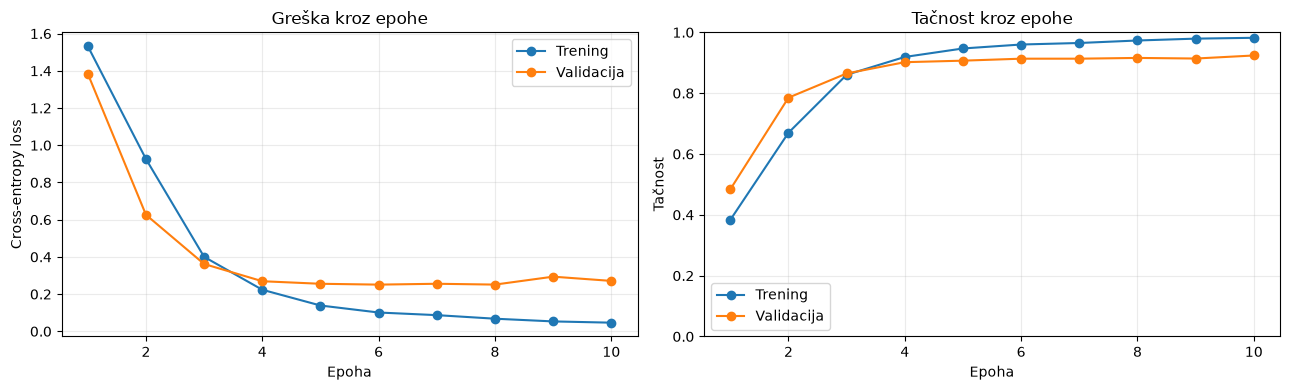

GRU_18 | emb=128, hidden=128, layers=1, dropout=0.3, lr=0.001


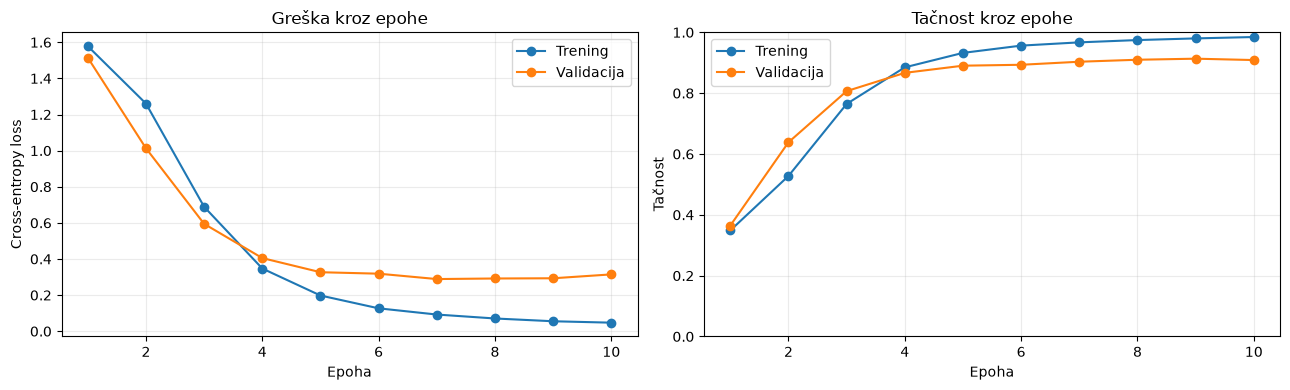

GRU_14 | emb=64, hidden=128, layers=1, dropout=0.3, lr=0.001


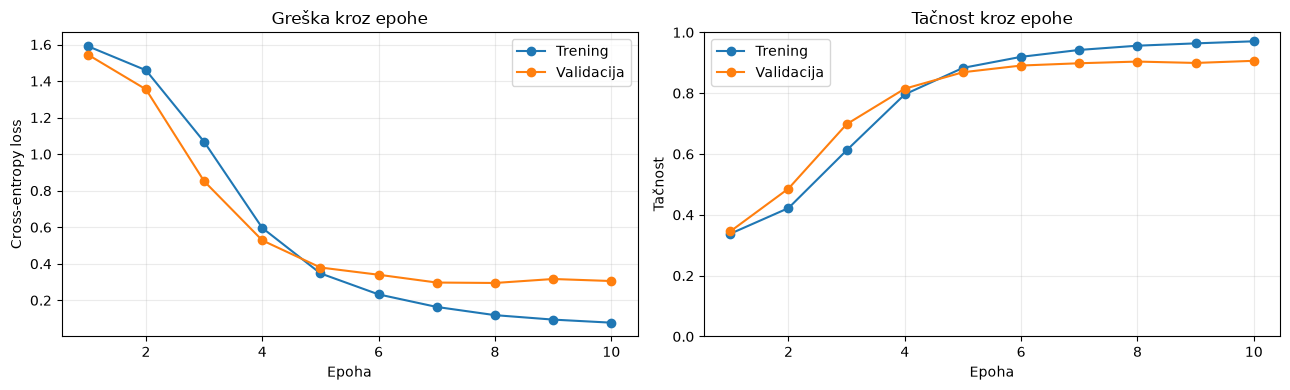

GRU_16 | emb=64, hidden=128, layers=2, dropout=0.4, lr=0.001


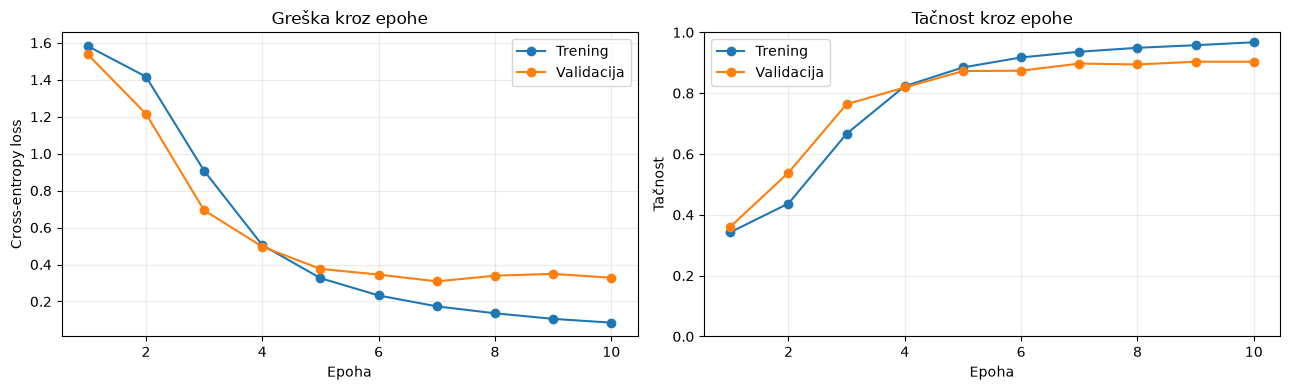

GRU_10 | emb=64, hidden=64, layers=1, dropout=0.2, lr=0.001


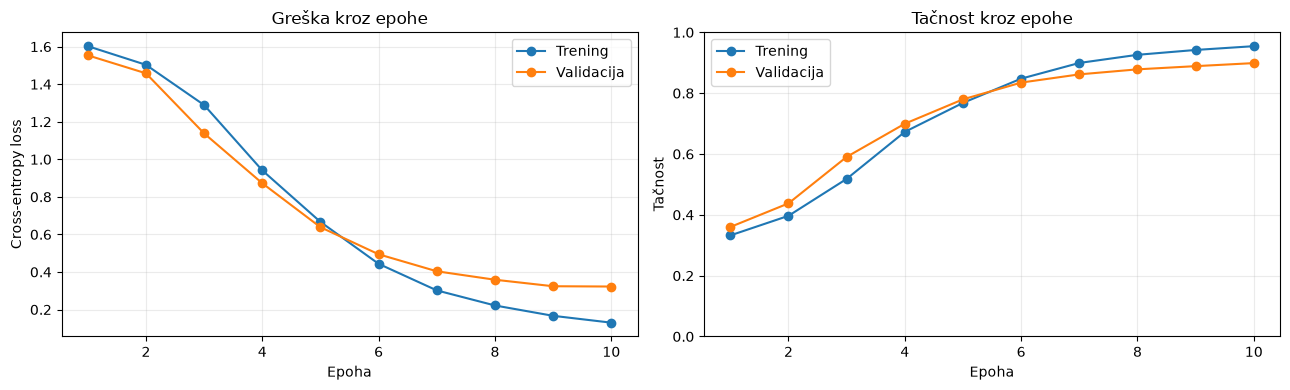

GRU_19 | emb=128, hidden=256, layers=2, dropout=0.5, lr=0.0005


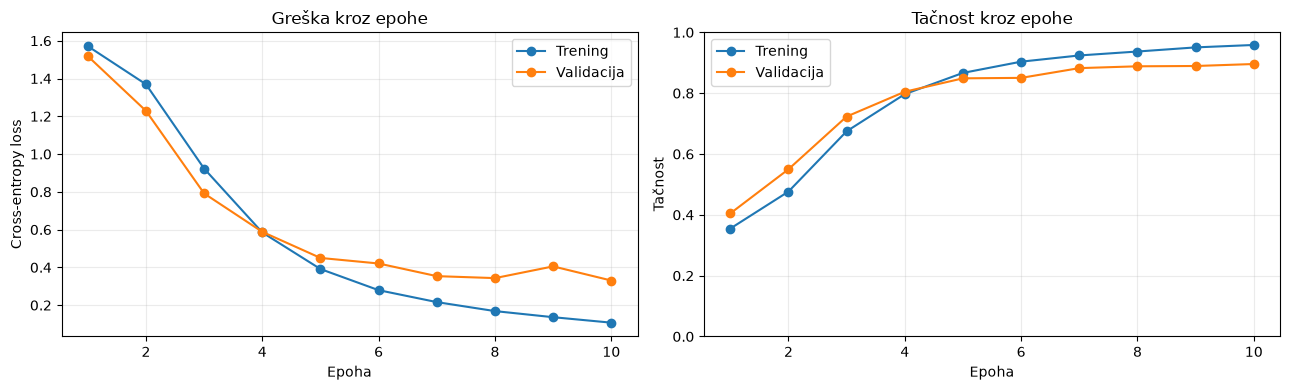

GRU_12 | emb=64, hidden=64, layers=2, dropout=0.4, lr=0.001


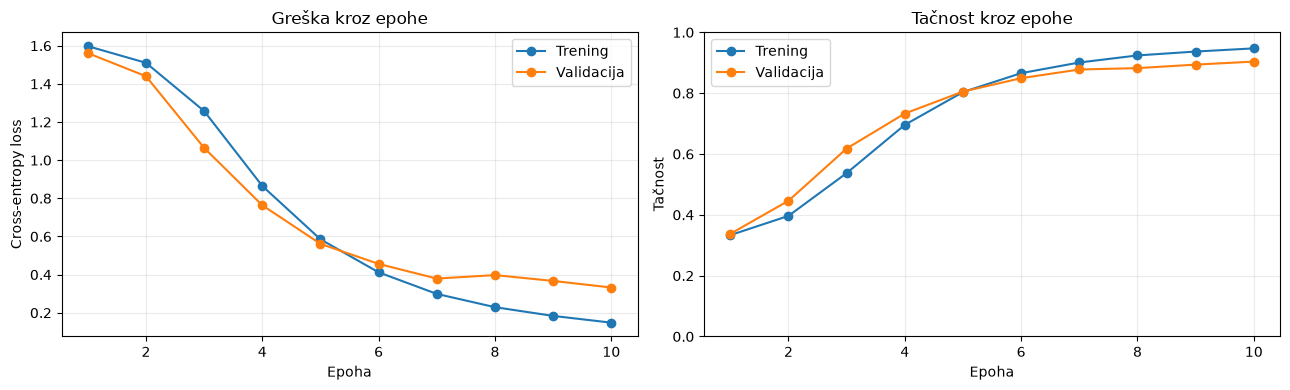

GRU_08 | emb=32, hidden=128, layers=2, dropout=0.3, lr=0.001


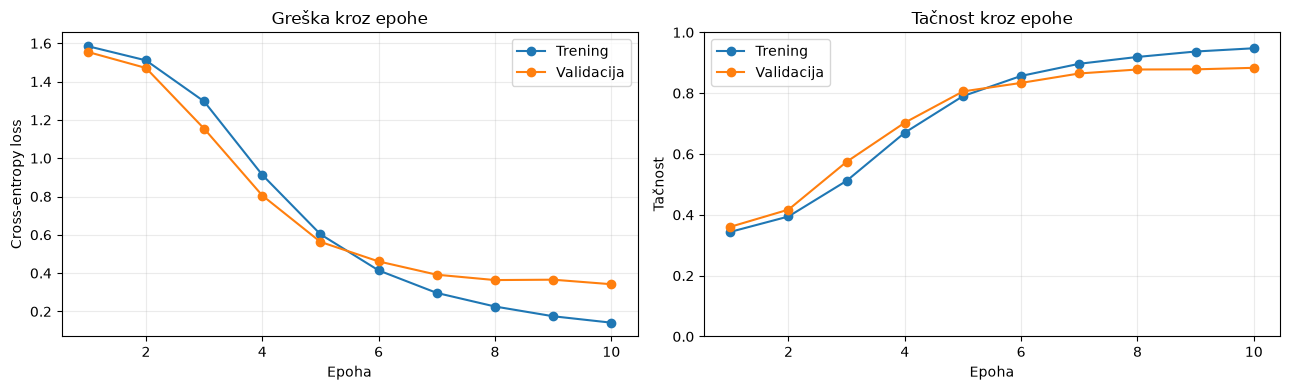

GRU_06 | emb=32, hidden=128, layers=1, dropout=0.3, lr=0.001


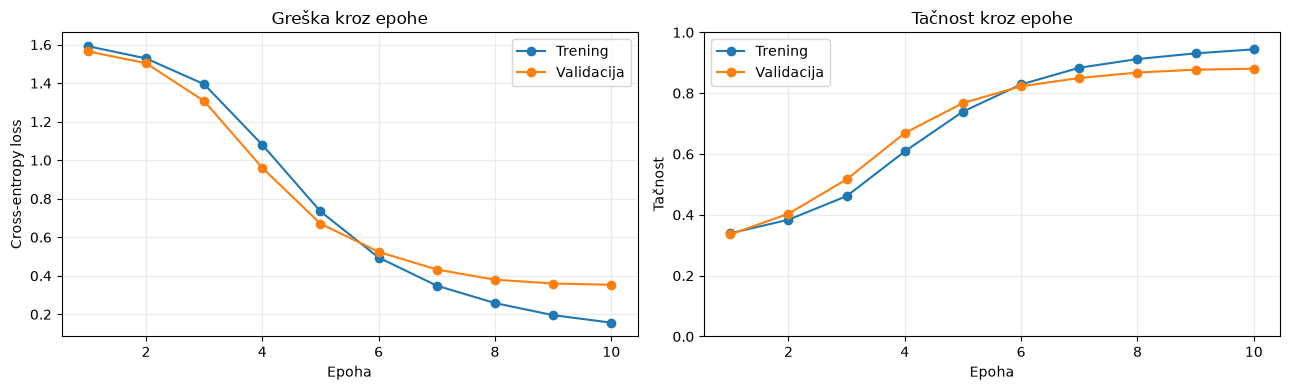

GRU_17 | emb=128, hidden=128, layers=1, dropout=0.3, lr=0.0005


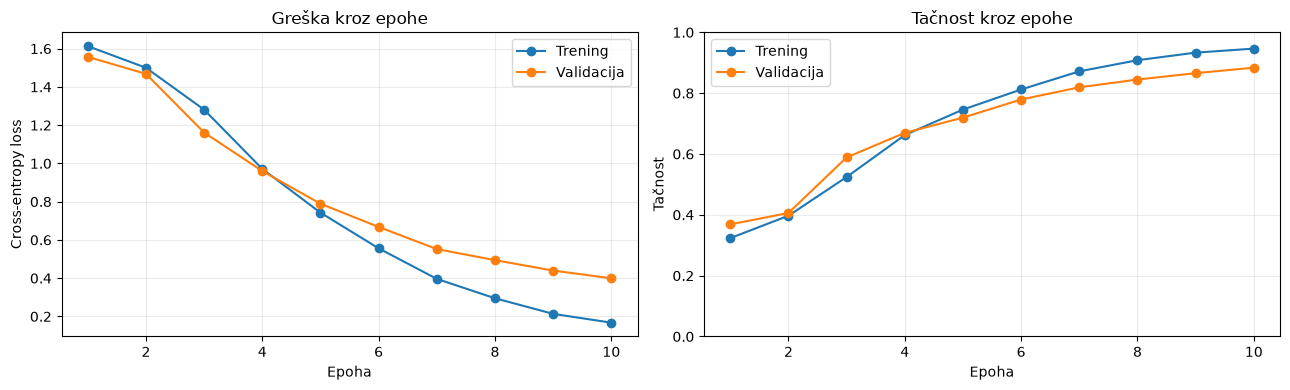

GRU_04 | emb=32, hidden=64, layers=2, dropout=0.2, lr=0.001


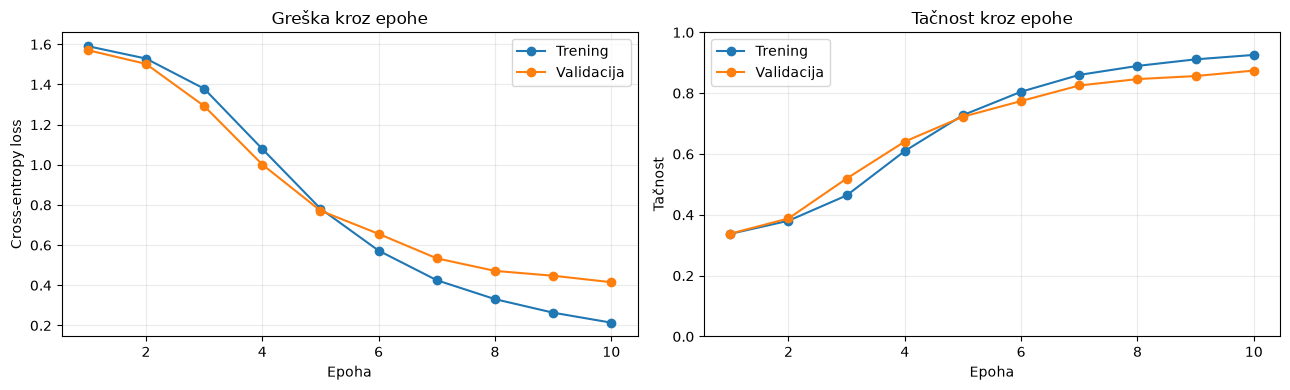

GRU_02 | emb=32, hidden=64, layers=1, dropout=0.2, lr=0.001


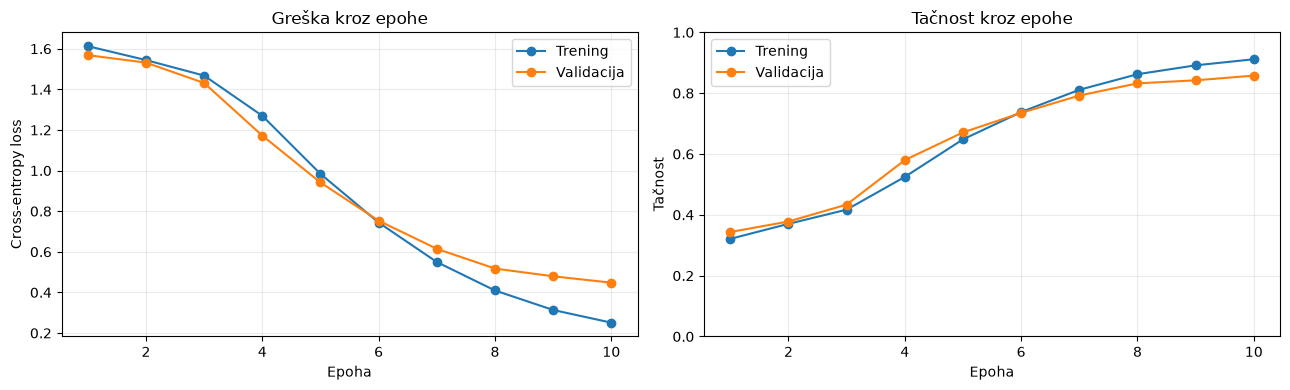

GRU_13 | emb=64, hidden=128, layers=1, dropout=0.3, lr=0.0005


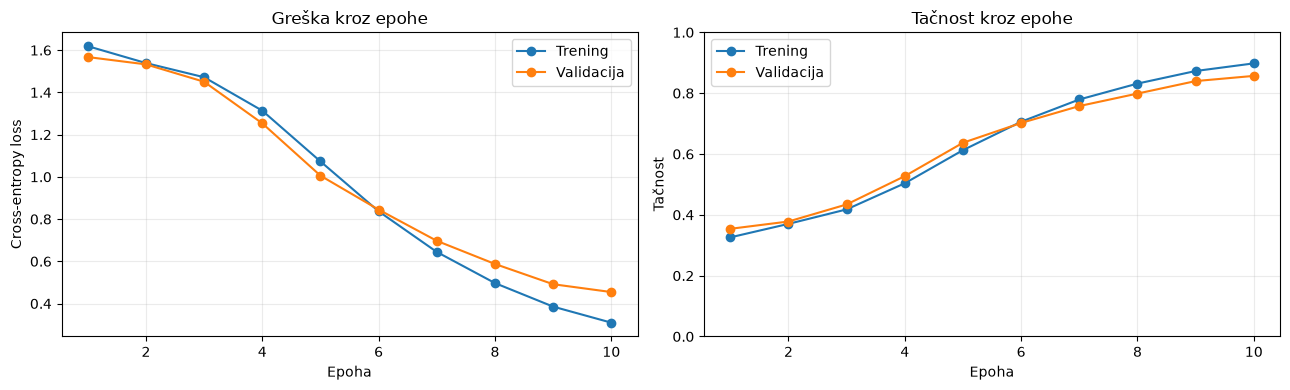

GRU_15 | emb=64, hidden=128, layers=2, dropout=0.4, lr=0.0005


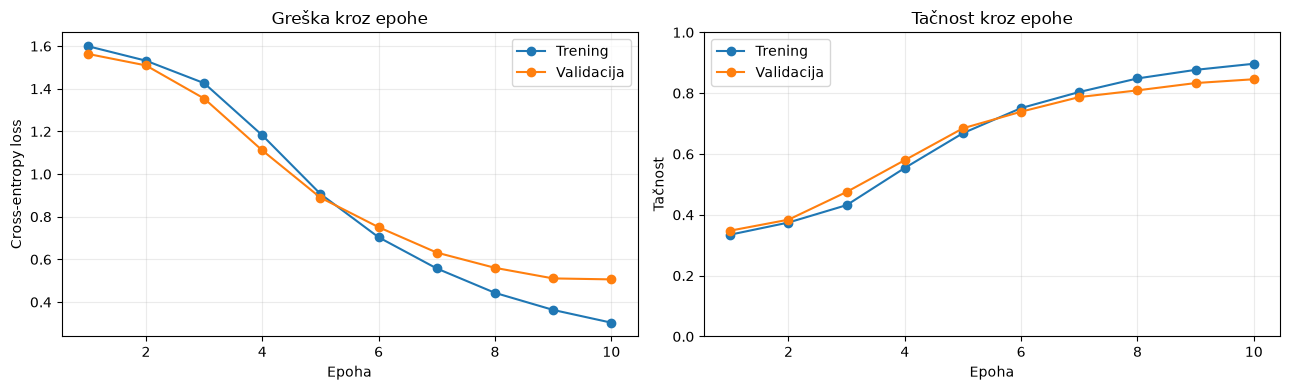

GRU_11 | emb=64, hidden=64, layers=2, dropout=0.4, lr=0.0005


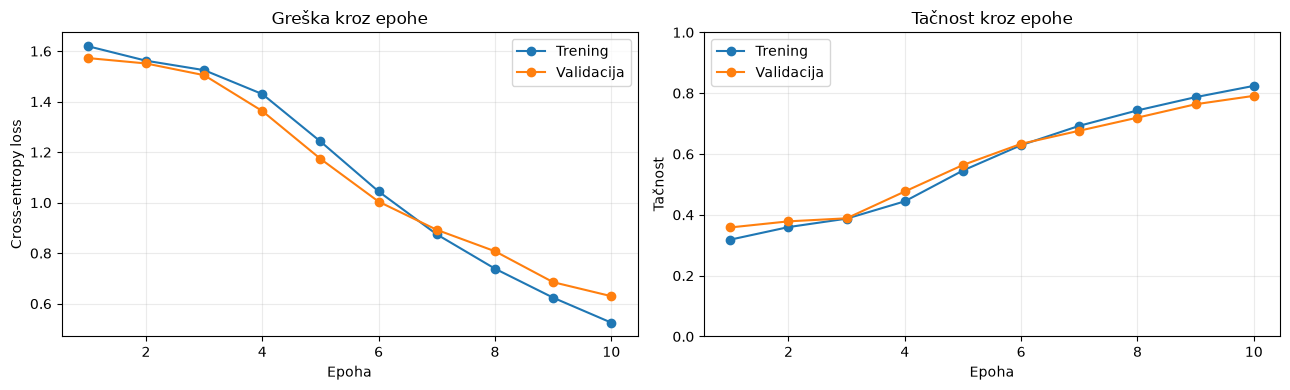

GRU_07 | emb=32, hidden=128, layers=2, dropout=0.3, lr=0.0005


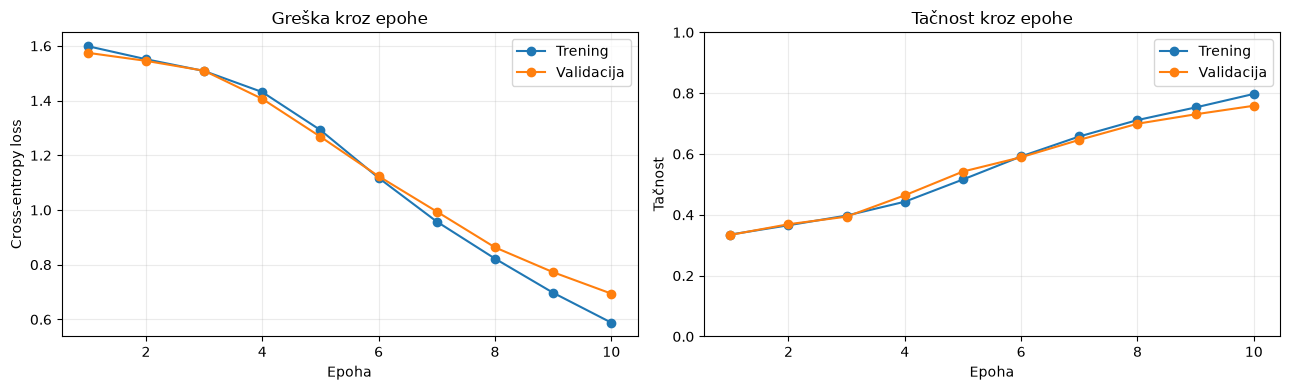

GRU_05 | emb=32, hidden=128, layers=1, dropout=0.3, lr=0.0005


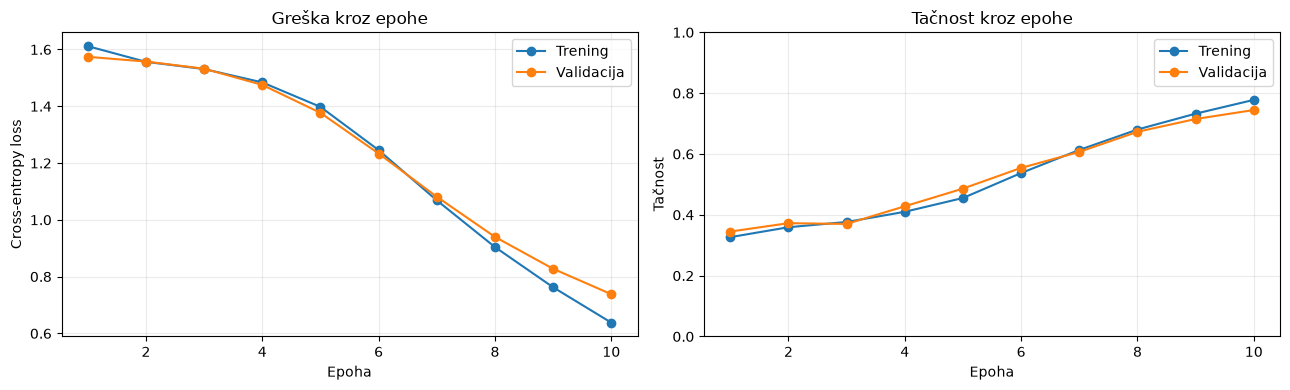

GRU_09 | emb=64, hidden=64, layers=1, dropout=0.2, lr=0.0005


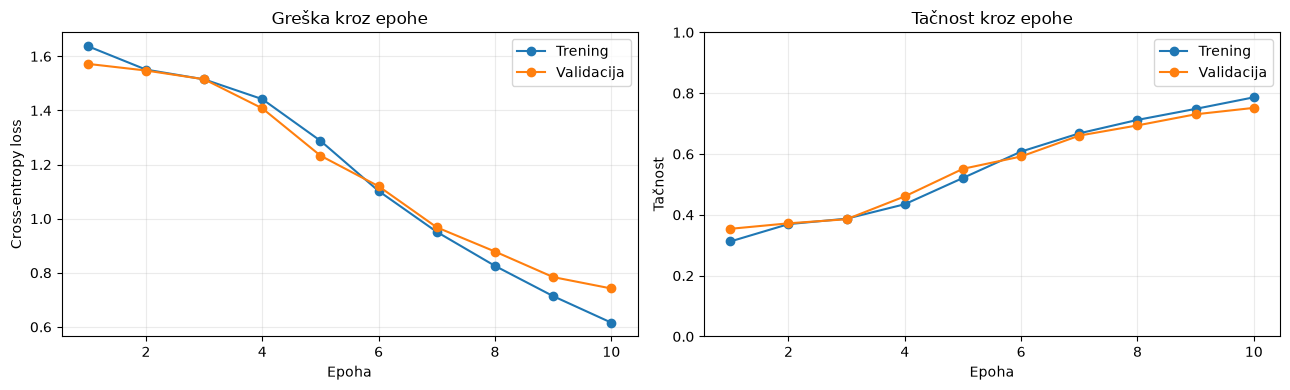

GRU_03 | emb=32, hidden=64, layers=2, dropout=0.2, lr=0.0005


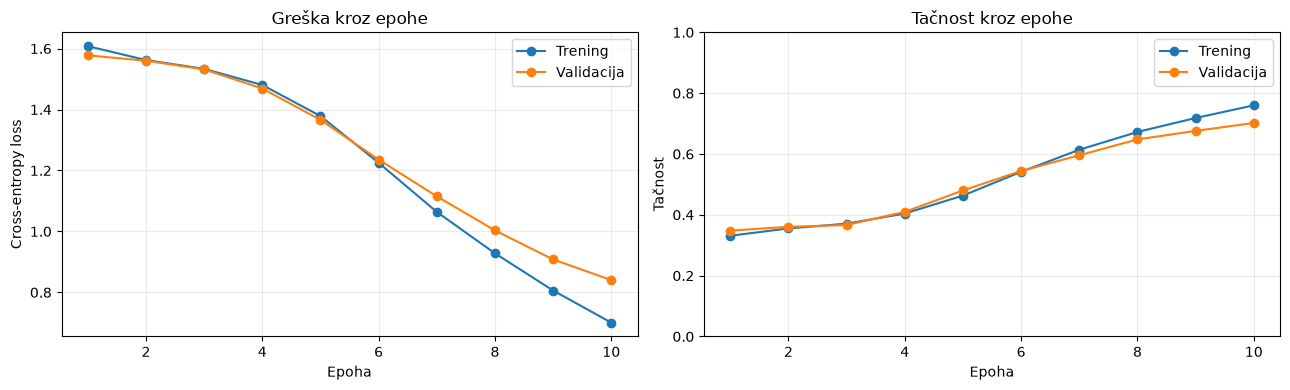

GRU_01 | emb=32, hidden=64, layers=1, dropout=0.2, lr=0.0005


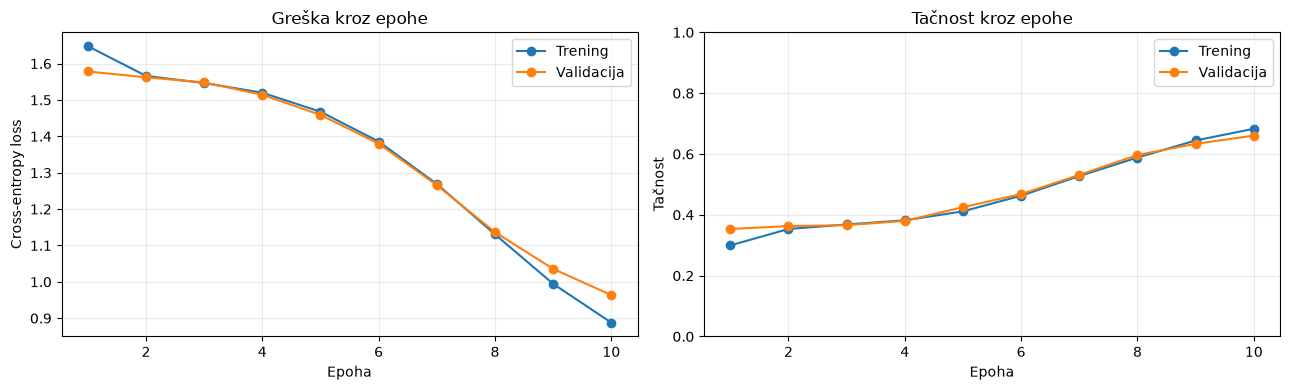

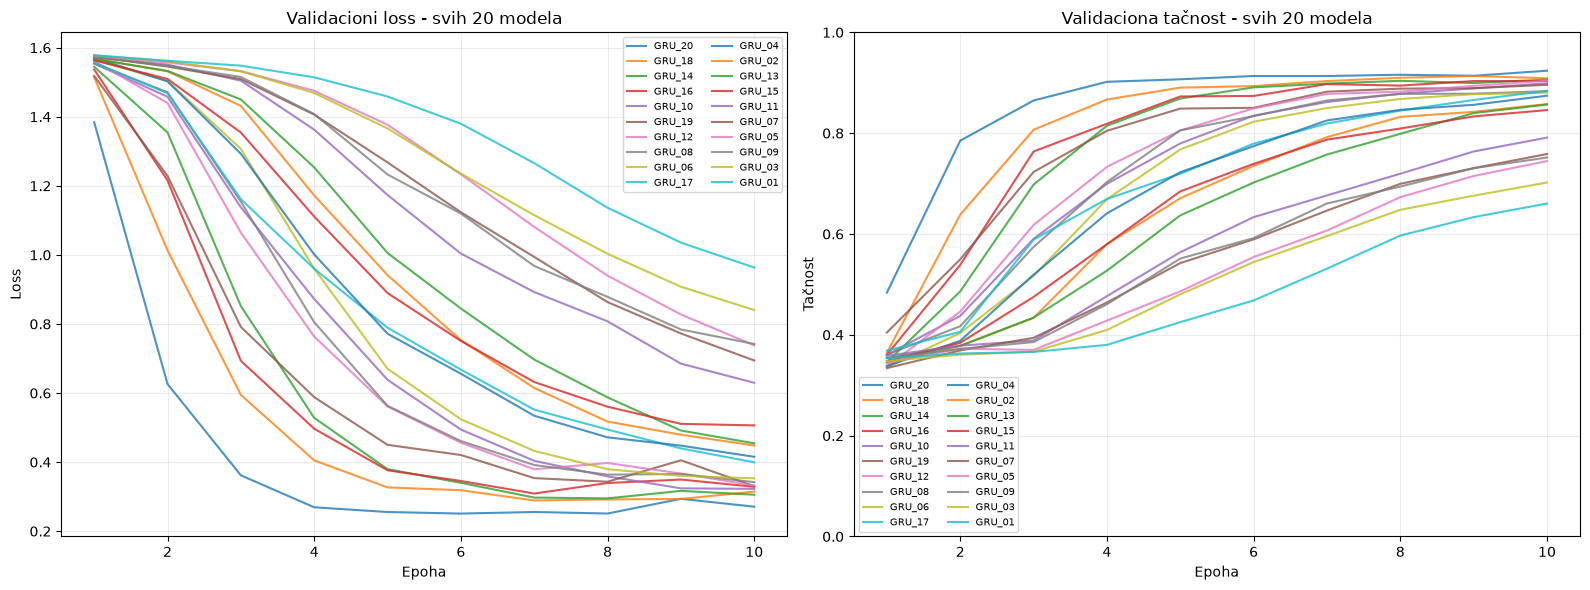

In [5]:
# Isti prikaz kao originalni plot_history, jednom za svaku konfiguraciju.
PLOT_EACH_HISTORY = True

if PLOT_EACH_HISTORY:
    for result in ranked_results:
        name = result['name']
        print(
            f'{name} | emb={result["embedding_dim"]}, '
            f'hidden={result["hidden_size"]}, layers={result["num_layers"]}, '
            f'dropout={result["dropout"]}, lr={result["learning_rate"]}'
        )
        plot_history(experiment_histories[name])

# Zajednički pregled validacionih krivih svih 20 modela.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for result in ranked_results:
    name = result['name']
    current_history = experiment_histories[name]
    epochs = range(1, len(current_history['val_loss']) + 1)
    axes[0].plot(epochs, current_history['val_loss'], label=name, alpha=0.8)
    axes[1].plot(epochs, current_history['val_accuracy'], label=name, alpha=0.8)

axes[0].set(title='Validacioni loss - svih 20 modela', xlabel='Epoha', ylabel='Loss')
axes[1].set(
    title='Validaciona tačnost - svih 20 modela',
    xlabel='Epoha',
    ylabel='Tačnost',
    ylim=(0, 1),
)
for axis in axes:
    axis.grid(alpha=0.25)
    axis.legend(ncol=2, fontsize=7)
plt.tight_layout()
plt.show()

## Evaluacija modela

Evaluacija najboljeg modela: GRU_20
Parametri: {'embedding_dim': 128, 'hidden_size': 256, 'num_layers': 2, 'dropout': 0.5, 'learning_rate': 0.001}


Evaluacija:   0%|          | 0/16 [00:00<?, ?it/s]

Test greška:  0.2921
Test tačnost: 0.9060

              precision    recall  f1-score   support

       anger     0.9132    0.8800    0.8963       275
        fear     0.8200    0.9152    0.8650       224
         joy     0.9150    0.9453    0.9299       695
        love     0.8239    0.8239    0.8239       159
     sadness     0.9574    0.9277    0.9423       581
    surprise     0.8444    0.5758    0.6847        66

    accuracy                         0.9060      2000
   macro avg     0.8790    0.8446    0.8570      2000
weighted avg     0.9069    0.9060    0.9051      2000



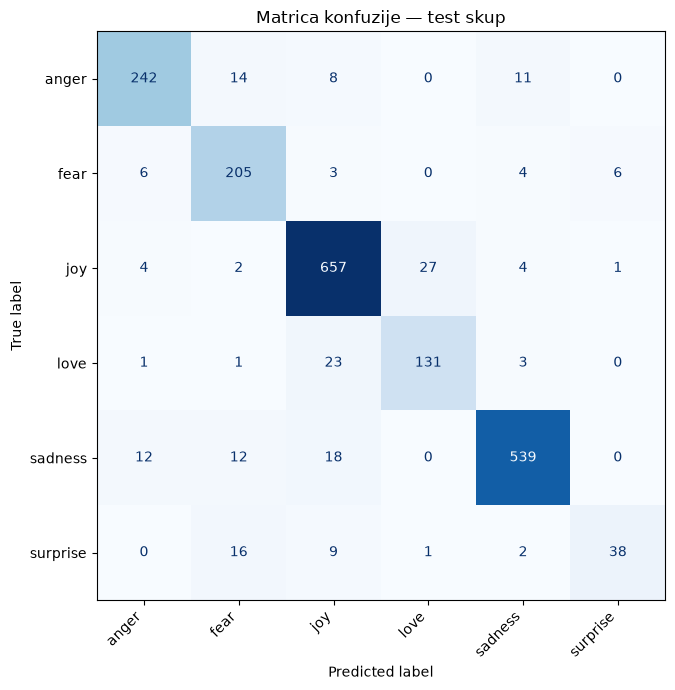

In [6]:
print(f'Evaluacija najboljeg modela: {best_model_name}')
print('Parametri:', {
    key: best_result[key]
    for key in ('embedding_dim', 'hidden_size', 'num_layers', 'dropout', 'learning_rate')
})
test_loss, test_accuracy, y_true, y_pred = print_evaluation(
    model, test_loader, label_names, device
)

label_indices = list(range(len(label_names)))
report = classification_report(
    y_true,
    y_pred,
    labels=label_indices,
    target_names=label_names,
    digits=4,
    zero_division=0,
)
(RESULTS_DIR / 'gru_classification_report.txt').write_text(
    report, encoding='utf-8'
)
plt.gcf().savefig(
    RESULTS_DIR / 'gru_confusion_matrix.png',
    bbox_inches='tight',
)
print(f'Rezultati su sačuvani u: {RESULTS_DIR}')

### Analiza rezultata

Najbolja GRU konfiguracija koristi embedding dim `128`, hidden size `256`, `2` GRU sloja, dropout `0.5` i learning rate `1e-3`, a najmanji validacioni loss postiže nakon 6 epoha.

Na test skupu model postiže Accuracy od `0.9060` i Macro F1 od `0.8570`.

Najbolji rezultati ostvareni su za klase `sadness`, `joy` i `anger`. Slabiji rezultati primećuju se kod manjinskih klasa `love` i `surprise`, što je očekivano zbog manje zastupljenosti ovih klasa u trening skupu.

Macro F1 je niži od Accuracy metrike jer svim klasama daje jednak značaj, uključujući i slabije zastupljene klase.